# Air Quality Model Enhancement with Lagged Features

This notebook demonstrates how to enhance air quality prediction models by adding lagged features (1, 2, and 3 days) using data from Hopsworks Feature Store.

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", module="IPython")

def is_google_colab():
    try:
        import google.colab
        return True
    except:
        return False

if is_google_colab():
    !git clone https://github.com/featurestorebook/mlfs-book.git
    %cd mlfs-book
    !pip install --upgrade uv
    !uv pip install --all-extras --system --requirement pyproject.toml
    root_dir = str(Path().absolute())
else:
    root_dir = Path().absolute()
    if root_dir.parts[-1:] == ('airquality',):
        root_dir = Path(*root_dir.parts[:-1])
    if root_dir.parts[-1:] == ('notebooks',):
        root_dir = Path(*root_dir.parts[:-1])
    root_dir = str(root_dir)

if root_dir not in sys.path:
    sys.path.append(root_dir)

from mlfs import config
settings = config.HopsworksSettings(_env_file=f"{root_dir}/.env")

HopsworksSettings initialized!


In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from datetime import datetime, date
import hopsworks
import os
import warnings
warnings.filterwarnings("ignore")

## Create Lagged Features Function

In [3]:
def create_lagged_features(df, target_col='pm25', lags=[1, 2, 3]):
    """Create lagged features for the target variable"""
    df_with_lags = df.copy()
    
    # Sort by date to ensure proper lag calculation
    df_with_lags = df_with_lags.sort_values('date').reset_index(drop=True)
    
    # Create lagged features
    for lag in lags:
        df_with_lags[f'{target_col}_lag_{lag}'] = df_with_lags[target_col].shift(lag)
    
    # Drop rows with NaN values (first few rows due to lagging)
    df_with_lags = df_with_lags.dropna().reset_index(drop=True)
    
    return df_with_lags

## Visualization Function

In [4]:
def create_visualizations(baseline_mse, baseline_r2, mse_lagged, r2_lagged, 
                         importance_df, mse_improvement, r2_improvement):
    """Create visualization plots"""
    
    # Create output directory
    images_dir = "air_quality_model/images"
    if not os.path.exists("air_quality_model"):
        os.mkdir("air_quality_model")
    if not os.path.exists(images_dir):
        os.mkdir(images_dir)
    
    # Plot 1: Feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(importance_df)), importance_df['importance'])
    plt.yticks(range(len(importance_df)), importance_df['feature'])
    plt.xlabel('Feature Importance')
    plt.title('XGBoost Feature Importance (with Lagged Features)')
    plt.tight_layout()
    plt.savefig(f'{images_dir}/feature_importance_with_lags.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Plot 2: Performance comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # MSE comparison
    models = ['Baseline\n(Weather only)', 'With Lagged\nFeatures']
    mse_values = [baseline_mse, mse_lagged]
    bars1 = ax1.bar(models, mse_values, color=['lightcoral', 'lightblue'])
    ax1.set_ylabel('Mean Squared Error')
    ax1.set_title('MSE Comparison')
    
    # Add improvement percentage
    if mse_improvement > 0:
        ax1.text(1, mse_lagged + max(mse_values)*0.05, f'{mse_improvement:.1f}%\nimprovement', 
                ha='center', va='bottom', fontweight='bold', color='green')
    
    # R² comparison
    r2_values = [baseline_r2, r2_lagged]
    bars2 = ax2.bar(models, r2_values, color=['lightcoral', 'lightblue'])
    ax2.set_ylabel('R² Score')
    ax2.set_title('R² Score Comparison')
    
    # Add improvement percentage
    if r2_improvement > 0:
        ax2.text(1, r2_lagged + max(r2_values)*0.05, f'{r2_improvement:.1f}%\nimprovement', 
                ha='center', va='bottom', fontweight='bold', color='green')
    
    plt.tight_layout()
    plt.savefig(f'{images_dir}/performance_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

## Main Model Comparison Function

In [5]:
def compare_models(X_train, y_train, X_test, y_test, test_start_date):
    """Compare baseline model with lagged features model"""
    
    print("="*60)
    print("AIR QUALITY MODEL ENHANCEMENT WITH LAGGED FEATURES")
    print("="*60)
    
    # Train baseline model (weather features only)
    print("\nTraining baseline model (weather features only)...")
    X_train_baseline = X_train.drop(columns=['date'])
    X_test_baseline = X_test.drop(columns=['date'])
    
    baseline_model = XGBRegressor(random_state=42)
    baseline_model.fit(X_train_baseline, y_train.iloc[:,0])
    
    y_pred_baseline = baseline_model.predict(X_test_baseline)
    baseline_mse = mean_squared_error(y_test.iloc[:,0], y_pred_baseline)
    baseline_r2 = r2_score(y_test.iloc[:,0], y_pred_baseline)
    
    print(f"\nBaseline Model Performance (weather features only):")
    print(f"MSE: {baseline_mse:.5f}")
    print(f"R²: {baseline_r2:.5f}")
    
    # Combine training and test data to create lagged features properly
    all_data = pd.concat([X_train.assign(pm25=y_train.iloc[:,0]), 
                          X_test.assign(pm25=y_test.iloc[:,0])], 
                         ignore_index=True)
    
    # Create lagged features
    all_data_with_lags = create_lagged_features(all_data)
    
    # Split back into train and test sets
    train_mask = all_data_with_lags['date'] < test_start_date
    test_mask = all_data_with_lags['date'] >= test_start_date
    
    X_train_lagged = all_data_with_lags[train_mask].drop(['pm25'], axis=1)
    y_train_lagged = all_data_with_lags[train_mask]['pm25']
    
    X_test_lagged = all_data_with_lags[test_mask].drop(['pm25'], axis=1)
    y_test_lagged = all_data_with_lags[test_mask]['pm25']
    
    print(f"\nDataset with lagged features:")
    print(f"Training set: {X_train_lagged.shape}")
    print(f"Test set: {X_test_lagged.shape}")
    print(f"New lagged features: {[col for col in X_train_lagged.columns if 'lag' in col]}")
    
    # Prepare features for training (remove date column)
    X_train_lagged_features = X_train_lagged.drop(columns=['date'])
    X_test_lagged_features = X_test_lagged.drop(columns=['date'])
    
    print(f"\nAll features: {list(X_train_lagged_features.columns)}")
    
    return X_train_lagged_features, X_test_lagged_features, y_train_lagged, y_test_lagged, baseline_mse, baseline_r2

## Train Model with Lagged Features

In [6]:
def train_and_evaluate_lagged_model(X_train_lagged_features, X_test_lagged_features, 
                                   y_train_lagged, y_test_lagged, baseline_mse, baseline_r2):
    # Train model with lagged features
    print("\nTraining XGBoost model with lagged features...")
    xgb_regressor_lagged = XGBRegressor(random_state=42)
    xgb_regressor_lagged.fit(X_train_lagged_features, y_train_lagged)
    
    # Make predictions with lagged model
    y_pred_lagged = xgb_regressor_lagged.predict(X_test_lagged_features)
    
    # Calculate performance metrics for lagged model
    mse_lagged = mean_squared_error(y_test_lagged, y_pred_lagged)
    r2_lagged = r2_score(y_test_lagged, y_pred_lagged)
    
    print(f"\nModel with Lagged Features Performance:")
    print(f"MSE: {mse_lagged:.5f}")
    print(f"R²: {r2_lagged:.5f}")
    
    return xgb_regressor_lagged, y_pred_lagged, mse_lagged, r2_lagged

## Performance Analysis

In [7]:
def analyze_performance(baseline_mse, baseline_r2, mse_lagged, r2_lagged, 
                       xgb_regressor_lagged, X_train_lagged_features):
    # Compare performance
    print(f"\n" + "="*60)
    print("PERFORMANCE COMPARISON")
    print("="*60)
    
    mse_improvement = ((baseline_mse - mse_lagged) / baseline_mse) * 100
    r2_improvement = ((r2_lagged - baseline_r2) / abs(baseline_r2)) * 100 if baseline_r2 != 0 else float('inf')
    
    print(f"Baseline Model (weather features only):")
    print(f"  MSE: {baseline_mse:.5f}")
    print(f"  R²: {baseline_r2:.5f}")
    print(f"\nModel with Lagged Features:")
    print(f"  MSE: {mse_lagged:.5f}")
    print(f"  R²: {r2_lagged:.5f}")
    print(f"\nImprovement:")
    print(f"  MSE: {mse_improvement:.2f}% {'improvement' if mse_improvement > 0 else 'degradation'}")
    print(f"  R²: {r2_improvement:.2f}% {'improvement' if r2_improvement > 0 else 'degradation'}")
    
    return mse_improvement, r2_improvement

## Feature Importance Analysis

In [8]:
def analyze_feature_importance(xgb_regressor_lagged, X_train_lagged_features):
    # Feature importance analysis
    print(f"\n" + "="*60)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("="*60)
    
    feature_importance = xgb_regressor_lagged.feature_importances_
    feature_names = X_train_lagged_features.columns
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)
    
    print("\nFeature Importance (sorted by importance):")
    for idx, row in importance_df.iterrows():
        print(f"  {row['feature']}: {row['importance']:.4f}")
    
    # Analysis of lagged features specifically
    lag_features = importance_df[importance_df['feature'].str.contains('lag')]
    if not lag_features.empty:
        print(f"\nLagged Feature Analysis:")
        total_lag_importance = lag_features['importance'].sum()
        total_importance = importance_df['importance'].sum()
        lag_contribution = (total_lag_importance / total_importance) * 100
        
        print(f"  Total contribution of lagged features: {lag_contribution:.2f}%")
        print(f"  Individual lagged feature importance:")
        for idx, row in lag_features.iterrows():
            contribution = (row['importance'] / total_importance) * 100
            print(f"    {row['feature']}: {contribution:.2f}% of total importance")
    
    return importance_df

## Results Explanation

In [9]:
def explain_results(mse_improvement, r2_improvement, X_train_lagged_features):
    # Explanation of results
    print(f"\n" + "="*60)
    print("ANALYSIS AND EXPLANATION")
    print("="*60)
    
    if mse_improvement > 0:
        print(f"✓ The addition of lagged air quality features IMPROVED the model performance.")
        print(f"  - MSE decreased by {mse_improvement:.2f}%, indicating better prediction accuracy")
        print(f"  - R² {'increased' if r2_improvement > 0 else 'changed'} by {abs(r2_improvement):.2f}%")
        print(f"\nWhy lagged features help:")
        print(f"  1. Air quality has temporal dependencies - today's pollution affects tomorrow's")
        print(f"  2. Weather patterns and pollution sources have persistence over multiple days")
        print(f"  3. Lagged features capture the 'memory' of the atmospheric system")
        print(f"  4. Previous day's PM2.5 levels are strong predictors of current levels")
    else:
        print(f"⚠ The addition of lagged air quality features did NOT improve the model performance.")
        print(f"  - MSE increased by {abs(mse_improvement):.2f}%, indicating worse prediction accuracy")
        print(f"  - This could be due to:")
        print(f"    1. Limited training data making the model overfit to lagged features")
        print(f"    2. The weather features already capturing most of the predictive signal")
        print(f"    3. The lagged features introducing noise rather than signal")
        print(f"    4. Need for feature engineering or different lag periods")
    
    print(f"\nModel Complexity:")
    print(f"  - Baseline model: 4 features (weather only)")
    print(f"  - Lagged model: {len(X_train_lagged_features.columns)} features")
    print(f"  - Added {len(X_train_lagged_features.columns) - 4} lagged features")

## Load Data from Hopsworks Feature Store

In [10]:
# Connect to Hopsworks
project = hopsworks.login(engine="python")
fs = project.get_feature_store()

# Get feature groups
air_quality_fg = fs.get_feature_group(name='air_quality', version=1)
weather_fg = fs.get_feature_group(name='weather', version=1)

print("Connected to Hopsworks Feature Store")

2025-11-18 19:31:04,186 INFO: Initializing external client
2025-11-18 19:31:04,187 INFO: Base URL: https://c.app.hopsworks.ai:443


2025-11-18 19:31:05,549 INFO: Python Engine initialized.

Logged in to project, explore it here https://c.app.hopsworks.ai:443/p/1292436
Connected to Hopsworks Feature Store


In [11]:
# Read data from feature groups
print("Loading air quality data...")
air_quality_df = air_quality_fg.read()

print("Loading weather data...")
weather_df = weather_fg.read()

print(f"Air quality data shape: {air_quality_df.shape}")
print(f"Weather data shape: {weather_df.shape}")

# Display data info
print("\nAir Quality Data:")
print(air_quality_df.head())
print("\nWeather Data:")
print(weather_df.head())

Loading air quality data...
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.10s) 
Loading weather data...
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.89s) 
Air quality data shape: (1140, 6)
Weather data shape: (1180, 6)

Air Quality Data:
                       date  pm25 country   city             street  \
0 2024-06-27 00:00:00+00:00  34.0  sweden  visby  visby-ostervag-17   
1 2025-06-04 00:00:00+00:00  45.0  sweden  visby  visby-ostervag-17   
2 2024-08-16 00:00:00+00:00  36.0  sweden  visby  visby-ostervag-17   
3 2023-11-26 00:00:00+00:00   9.0  sweden  visby  visby-ostervag-17   
4 2023-05-23 00:00:00+00:00  26.0  sweden  visby  visby-ostervag-17   

                                 url  
0  https://api.waqi.info/feed/@13987  
1  https://api.waqi.info/feed/@13987  
2  https://api.waqi.info/feed/@13987  
3  https://api.waqi.info/feed/@13987  
4  https://api.waqi.info/feed/@13987  

Weather Data:
                 

In [12]:
# Merge air quality and weather data
merged_df = pd.merge(air_quality_df, weather_df, on=['date', 'city'], how='inner')

# Sort by date
merged_df = merged_df.sort_values('date').reset_index(drop=True)

# Convert date column to datetime if needed
merged_df['date'] = pd.to_datetime(merged_df['date'])

print(f"Merged data shape: {merged_df.shape}")
print(f"Date range: {merged_df['date'].min()} to {merged_df['date'].max()}")
print("\nMerged data columns:")
print(merged_df.columns.tolist())
print("\nFirst few rows:")
merged_df.head()

Merged data shape: (1140, 10)
Date range: 2022-09-02 00:00:00+00:00 to 2025-11-18 00:00:00+00:00

Merged data columns:
['date', 'pm25', 'country', 'city', 'street', 'url', 'temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'wind_direction_10m_dominant']

First few rows:


,date,pm25,country,city,street,url,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant
0,2022-09-02 00:00:00+00:00,11.0,sweden,visby,visby-ostervag-17,https://api.waqi.info/feed/@13987,11.688001,0.0,15.978486,5.365952
1,2022-09-03 00:00:00+00:00,11.0,sweden,visby,visby-ostervag-17,https://api.waqi.info/feed/@13987,11.823417,0.1,8.913181,99.462227
2,2022-09-04 00:00:00+00:00,7.0,sweden,visby,visby-ostervag-17,https://api.waqi.info/feed/@13987,12.006748,3.8,11.592894,70.709900
3,2022-09-05 00:00:00+00:00,11.0,sweden,visby,visby-ostervag-17,https://api.waqi.info/feed/@13987,11.040085,0.1,12.303366,21.634533
4,2022-09-06 00:00:00+00:00,9.0,sweden,visby,visby-ostervag-17,https://api.waqi.info/feed/@13987,11.298416,0.0,13.551501,247.536728


In [13]:
# Prepare train/test split
# Use 80% for training, 20% for testing
split_date = merged_df['date'].quantile(0.8)

train_df = merged_df[merged_df['date'] < split_date].copy()
test_df = merged_df[merged_df['date'] >= split_date].copy()

print(f"Split date: {split_date}")
print(f"Training data: {len(train_df)} rows")
print(f"Test data: {len(test_df)} rows")

# Prepare features and target
feature_cols = ['temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'wind_direction_10m_dominant']
target_col = 'pm25'

X_train = train_df[['date'] + feature_cols].copy()
y_train = train_df[[target_col]].copy()
X_test = test_df[['date'] + feature_cols].copy()
y_test = test_df[[target_col]].copy()

print(f"\nFeature columns: {feature_cols}")
print(f"Target column: {target_col}")

Split date: 2025-03-27 04:48:00+00:00
Training data: 912 rows
Test data: 228 rows

Feature columns: ['temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'wind_direction_10m_dominant']
Target column: pm25


## Run Lagged Features Analysis

Now we'll run the complete analysis using the data from Hopsworks:

AIR QUALITY MODEL ENHANCEMENT WITH LAGGED FEATURES

Training baseline model (weather features only)...

Baseline Model Performance (weather features only):
MSE: 235.89362
R²: 0.00184

Dataset with lagged features:
Training set: (909, 8)
Test set: (228, 8)
New lagged features: ['pm25_lag_1', 'pm25_lag_2', 'pm25_lag_3']

All features: ['temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'wind_direction_10m_dominant', 'pm25_lag_1', 'pm25_lag_2', 'pm25_lag_3']

Training XGBoost model with lagged features...

Model with Lagged Features Performance:
MSE: 135.36188
R²: 0.42723

PERFORMANCE COMPARISON
Baseline Model (weather features only):
  MSE: 235.89362
  R²: 0.00184

Model with Lagged Features:
  MSE: 135.36188
  R²: 0.42723

Improvement:
  MSE: 42.62% improvement
  R²: 23176.29% improvement

FEATURE IMPORTANCE ANALYSIS

Feature Importance (sorted by importance):
  pm25_lag_1: 0.5505
  wind_direction_10m_dominant: 0.1269
  precipitation_sum: 0.0805
  wind_speed_10m_max: 0.07

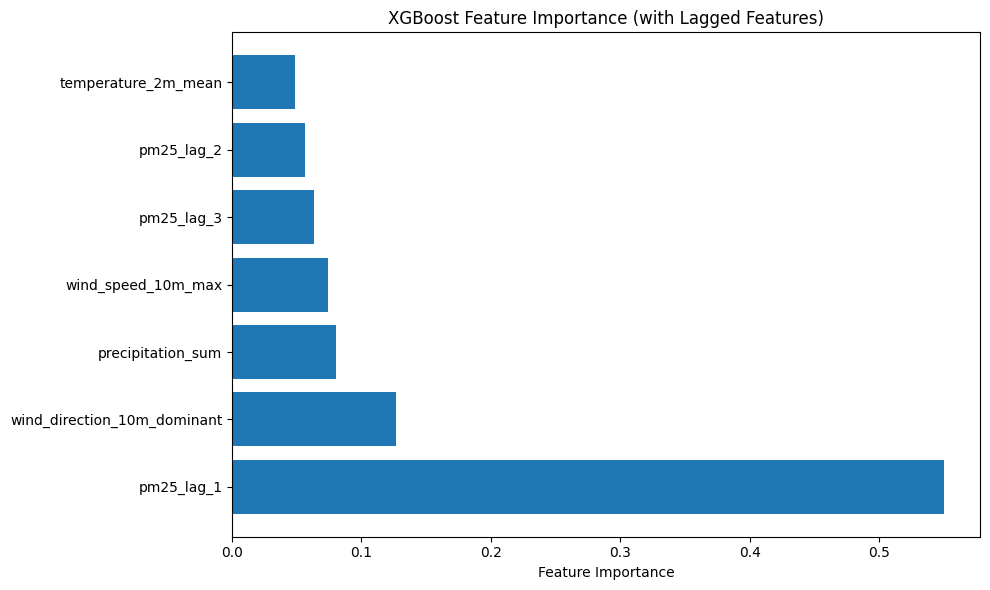

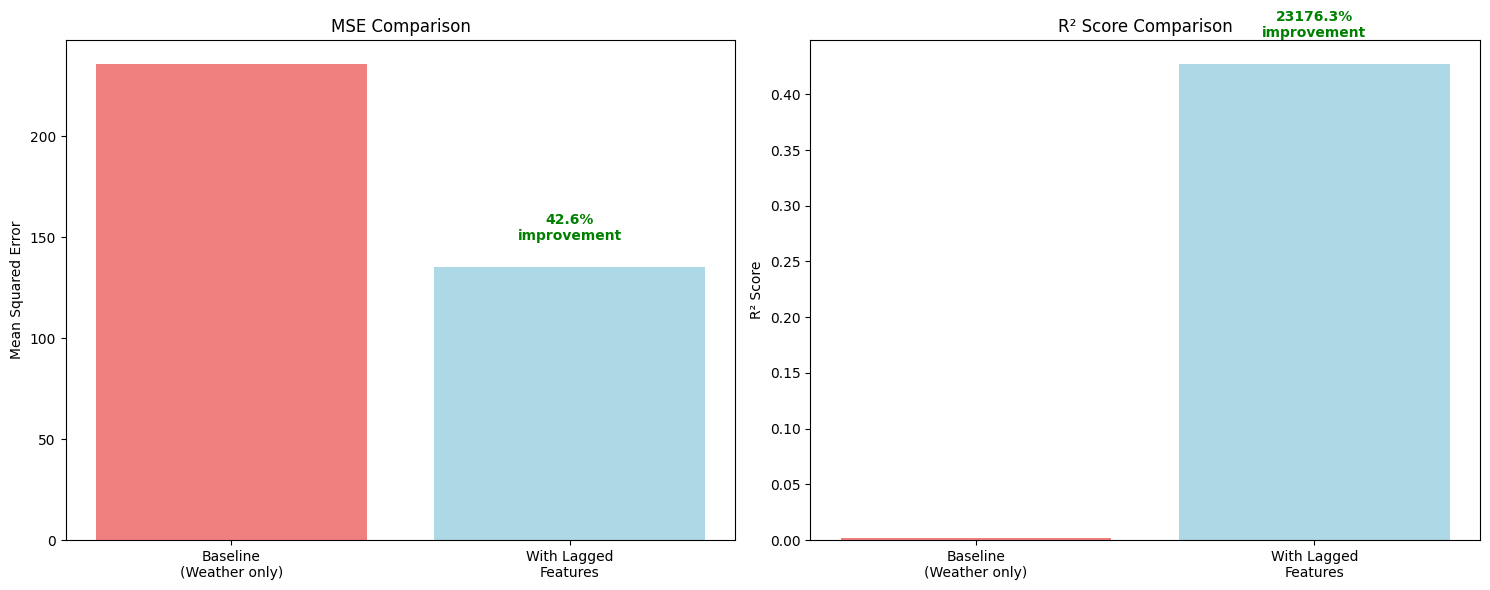


ANALYSIS AND EXPLANATION
✓ The addition of lagged air quality features IMPROVED the model performance.
  - MSE decreased by 42.62%, indicating better prediction accuracy
  - R² increased by 23176.29%

Why lagged features help:
  1. Air quality has temporal dependencies - today's pollution affects tomorrow's
  2. Weather patterns and pollution sources have persistence over multiple days
  3. Lagged features capture the 'memory' of the atmospheric system
  4. Previous day's PM2.5 levels are strong predictors of current levels

Model Complexity:
  - Baseline model: 4 features (weather only)
  - Lagged model: 7 features
  - Added 3 lagged features


In [14]:
# Run the complete analysis
X_train_lagged_features, X_test_lagged_features, y_train_lagged, y_test_lagged, baseline_mse, baseline_r2 = compare_models(
    X_train, y_train, X_test, y_test, split_date
)

xgb_regressor_lagged, y_pred_lagged, mse_lagged, r2_lagged = train_and_evaluate_lagged_model(
    X_train_lagged_features, X_test_lagged_features, y_train_lagged, y_test_lagged, baseline_mse, baseline_r2
)

mse_improvement, r2_improvement = analyze_performance(
    baseline_mse, baseline_r2, mse_lagged, r2_lagged, xgb_regressor_lagged, X_train_lagged_features
)

importance_df = analyze_feature_importance(xgb_regressor_lagged, X_train_lagged_features)

create_visualizations(
    baseline_mse, baseline_r2, mse_lagged, r2_lagged, importance_df, mse_improvement, r2_improvement
)

explain_results(mse_improvement, r2_improvement, X_train_lagged_features)